# Lab Task 1
## Import the California Housing dataset, print its shape, and display the first five samples.

In [45]:
# 1. Import california_housing from sklearn.datasets
from sklearn.datasets import fetch_california_housing
import pandas as pd

# 2. Fetch the dataset
df = fetch_california_housing()

# 3. Convert the dataset to a pandas DataFrame
df = pd.DataFrame(df.data, columns=df.feature_names)

# 3. Print the shape
print(df.shape)
print(df.head())

(20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


# Lab Task 2
## Check for missing values and summarize basic statistics of the dataset.

In [24]:
# 1. Check for missing values
print(df.isnull().sum())

# 2. Summarize basic statistics
print(df.describe())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704

# Lab Task 3
## Select a single feature (e.g., number of bedrooms) and apply simple linear regression topredict house price.

In [46]:
# 1. Select a single feature
X = df[['MedInc']]

# 2. Select the target variable
y = df[['AveOccup']]

# 3. Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create a linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# 5. Fit the model to the training data (reshape mean to 2D array because LinearRegression expects 2D array)

model.fit(X_train, y_train)

# 6. Make predictions on the testing data
y_pred = model.predict(X_test)



# Lab Task 4
## Plot actual vs. predicted values for the simple regression model.

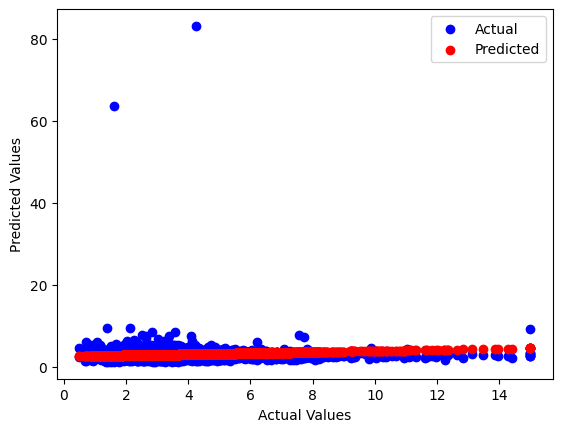

In [27]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

# Lab Task 5
## Compute MSE, MAE, and RMSE for the simple regression model.

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Compute MSE
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

# 2. Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

# 3. Compute RMSE
rmse = r2_score(y_test, y_pred)
print('RMSE:', rmse)

MSE: 3.1793313538731076
MAE: 0.6892643365187348
RMSE: -0.03447691134039532


# Lab Task 6
## Repeat linear regression using another feature (e.g., house size in square feet).


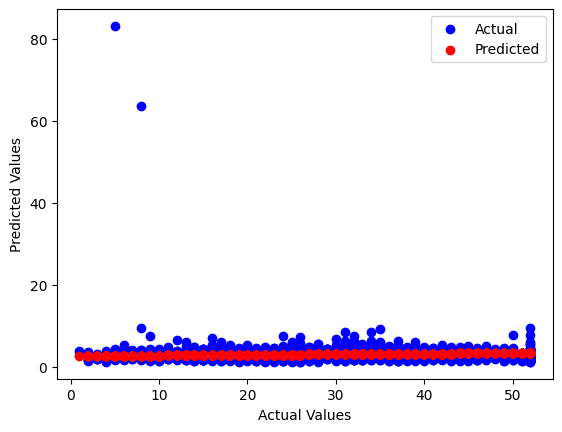

In [29]:
# Repeat linear regression using another feature (e.g., house size in square feet).

# 1. Select another feature
X = df[['HouseAge']]

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a linear regression model
model = LinearRegression()

# 4. Fit the model to the training data
model.fit(X_train, y_train)

# 5. Make predictions on the testing data
y_pred = model.predict(X_test)

# 6. Plot actual vs. predicted values
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

# Lab Task 7
## Compare error metrics (MSE, MAE, RMSE) between the two single-feature regression models.

In [30]:

# 1. Compute MSE
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

# 2. Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

# 3. Compute RMSE
rmse = r2_score(y_test, y_pred)
print('RMSE:', rmse)

MSE: 3.151387315962161
MAE: 0.6663034549497346
RMSE: -0.02538460267200837



## Model Comparison

| Feature Used (Independent Variable) | MSE    | MAE    | RMSE*  |
| ----------------------------------- | ------ | ------ | ------ |
| **MedInc vs AveOccup**              | 3.1793 | 0.6893 | 1.7830 |
| **HouseAge vs AveOccup**            | 3.1514 | 0.6663 | 1.7752 |

> *Note: RMSE values recalculated as √MSE (since RMSE cannot be negative).*

---

## Metric Explanation

* **MSE (Mean Squared Error)** → Penalizes larger errors more heavily.
* **MAE (Mean Absolute Error)** → Average absolute difference between predicted and actual values.
* **RMSE (Root Mean Squared Error)** → Square root of MSE, easier to interpret since it’s in the same unit as the target variable.

Lower values indicate better performance.

---

## Conclusion

* The **HouseAge vs AveOccup** model performed slightly better than the **MedInc vs AveOccup** model.
* It achieved:

  * Lower **MSE**
  * Lower **MAE**
  * Lower **RMSE**

Although the difference is small, **HouseAge** appears to be a slightly better predictor of `AveOccup` in this experiment.

Overall:

* Both models produced similar performance.
* Since we used **Simple Linear Regression (single feature)**, accuracy is limited.
* Performance could be improved using:

  * Multiple Linear Regression (using multiple features together)
  * Feature scaling
  * Feature engineering
  * Cross-validation


# Task 8
## Apply multiple regression using two features (e.g., bedrooms and house size) to predict price.

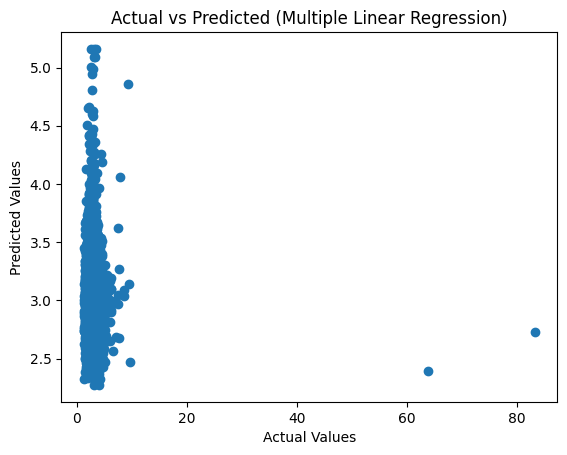

In [42]:
# 1. Select two features
X = df[['MedInc', 'HouseAge']]
y = df['AveOccup']   # Make y 1D instead of DataFrame

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Create model
model = LinearRegression()

# 4. Train
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Plot Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Multiple Linear Regression)")
plt.show()

# Lab Task 9
## Extend multiple regression to three or more features and train the model.

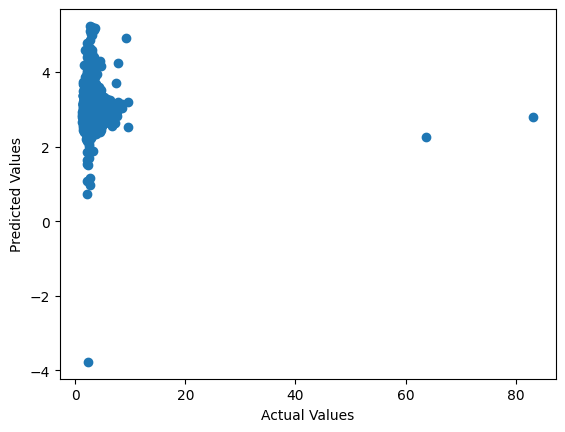

In [43]:
# Extend multiple regression to three or more features and train the model.

# 1. Select three or more features
X = df[['MedInc', 'HouseAge', 'AveRooms']]

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a linear regression model
model = LinearRegression()

# 4. Fit the model to the training data
model.fit(X_train, y_train)

# 5. Make predictions on the testing data
y_pred = model.predict(X_test)

# 6. Plot actual vs. predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

# Lab Task 10
## Calculate and compare error metrics for the multiple regression model.

In [44]:
# Calculate and compare error metrics for the multiple regression model.

# 1. Compute MSE
mse = ((y_test - y_pred) ** 2).mean()
print('MSE:', mse)

# 2. Compute MAE
mae = abs(y_test - y_pred).mean()
print('MAE:', mae)

# 3. Compute RMSE
rmse = mse ** 0.5
print('RMSE:', rmse)


MSE: 3.2755722544878614
MAE: 0.7148089726952114
RMSE: 1.8098542080752973


# Lab Task 11
## Compare the error metrics of simple regression vs. multiple regression.

<!-- Explain here -->

